In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Example: Set dataset path
dataset_path = "/content/drive/MyDrive/AI_Tracefinder"




Mounted at /content/drive


                                        Preprocessing on Official and Wikipedia

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

# --- Paths ---
DATASET_PATH = "/content/drive/MyDrive/AI_Tracefinder"
OUTPUT_PATH = os.path.join(DATASET_PATH, "Supatlantique_preprocessed_docs")
os.makedirs(OUTPUT_PATH, exist_ok=True)

IMG_SIZE = (224, 224)
EXTENSIONS = {".tif", ".png", ".jpg", ".jpeg"}

# --- Metadata ---
metadata_file = os.path.join(OUTPUT_PATH, "metadata_docs.csv")
metadata_df = pd.DataFrame()
new_metadata = []

def extract_residual(img):
    denoised = cv2.GaussianBlur(img, (5, 5), 0)
    residual = img.astype(np.float32) - denoised.astype(np.float32)
    residual = (residual - np.mean(residual)) / (np.std(residual) + 1e-8)
    return residual

def process_documents(class_name):
    class_path = os.path.join(DATASET_PATH, class_name)
    if os.path.isdir(class_path):
        for root, _, files in os.walk(class_path):
            image_files = [f for f in files if os.path.splitext(f)[1].lower() in EXTENSIONS]
            for file in image_files:
                file_path = os.path.join(root, file)
                img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    continue
                img_resized = cv2.resize(img, IMG_SIZE)
                residual = extract_residual(img_resized)

                relative_path = os.path.relpath(root, DATASET_PATH)
                save_dir = os.path.join(OUTPUT_PATH, relative_path)
                os.makedirs(save_dir, exist_ok=True)
                save_path = os.path.join(save_dir, file)
                cv2.imwrite(save_path, cv2.normalize(residual, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8))

                new_metadata.append({
                    "class": class_name,
                    "subfolder": relative_path,
                    "filename": file
                })

for folder in ["Official", "Wikipedia"]:
    print(f"🔄 Processing {folder} ...")
    process_documents(folder)

if new_metadata:
    metadata_df = pd.DataFrame(new_metadata)
    metadata_df.to_csv(metadata_file, index=False)

print("✅ Document preprocessing complete!")
print(metadata_df.head())


🔄 Processing Official ...
🔄 Processing Wikipedia ...
✅ Document preprocessing complete!
      class                subfolder  filename
0  Official  Official/Canon120-1/150  s1_1.tif
1  Official  Official/Canon120-1/150  s1_2.tif
2  Official  Official/Canon120-1/150  s1_3.tif
3  Official  Official/Canon120-1/150  s1_4.tif
4  Official  Official/Canon120-1/150  s1_5.tif


                                                      Preprocessing on Flatfield

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

# --- Paths ---
DATASET_PATH = "/content/drive/MyDrive/AI_Tracefinder"
OUTPUT_PATH = os.path.join(DATASET_PATH, "Supatlantique_preprocessed_flatfield")
os.makedirs(OUTPUT_PATH, exist_ok=True)

IMG_SIZE = (224, 224)
EXTENSIONS = {".tif", ".png", ".jpg", ".jpeg"}

# --- Metadata ---
metadata_file = os.path.join(OUTPUT_PATH, "metadata_flatfield.csv")
metadata_df = pd.DataFrame()
new_metadata = []

def extract_residual(img):
    denoised = cv2.GaussianBlur(img, (5, 5), 0)
    residual = img.astype(np.float32) - denoised.astype(np.float32)
    residual = (residual - np.mean(residual)) / (np.std(residual) + 1e-8)
    return residual

def process_flatfield():
    class_path = os.path.join(DATASET_PATH, "Flatfield")
    if os.path.isdir(class_path):
        for root, _, files in os.walk(class_path):
            image_files = [f for f in files if os.path.splitext(f)[1].lower() in EXTENSIONS]
            for file in image_files:
                file_path = os.path.join(root, file)
                img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    continue
                img_resized = cv2.resize(img, IMG_SIZE)
                residual = extract_residual(img_resized)

                relative_path = os.path.relpath(root, DATASET_PATH)
                save_dir = os.path.join(OUTPUT_PATH, relative_path)
                os.makedirs(save_dir, exist_ok=True)
                save_path = os.path.join(save_dir, file)
                cv2.imwrite(save_path, cv2.normalize(residual, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8))

                new_metadata.append({
                    "class": "Flatfield",
                    "subfolder": relative_path,
                    "filename": file
                })

print("🔄 Processing Flatfield ...")
process_flatfield()

if new_metadata:
    metadata_df = pd.DataFrame(new_metadata)
    metadata_df.to_csv(metadata_file, index=False)

print("✅ Flatfield preprocessing complete!")
print(metadata_df.head())


🔄 Processing Flatfield ...
✅ Flatfield preprocessing complete!
       class             subfolder filename
0  Flatfield  Flatfield/Canon120-1  300.tif
1  Flatfield  Flatfield/Canon120-1  150.tif
2  Flatfield  Flatfield/EpsonV39-1  300.tif
3  Flatfield  Flatfield/EpsonV39-1  150.tif
4  Flatfield  Flatfield/Canon120-2  300.tif


                                                              EDA Analysis

Counting the total images in dataset in a tabular form

In [15]:
import os
from tabulate import tabulate
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

def count_images_tif(dataset_path, extensions=None):
    if extensions is None:
        # Include .tif images
        extensions = {".tif"}

    class_counts = {}
    total_images = 0

    for class_name in os.listdir(dataset_path):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):
            subfolder_counts = {}
            class_total = 0
            # Walk recursively through all subfolders
            for root, dirs, files in os.walk(class_path):
                sub_count = sum(1 for f in files if os.path.splitext(f)[1].lower() in extensions)
                subfolder_name = os.path.relpath(root, dataset_path)
                subfolder_counts[subfolder_name] = sub_count
                class_total += sub_count

            # Print table for this class
            print(f"\nClass: {class_name}")
            table = [[sub, cnt] for sub, cnt in subfolder_counts.items()]
            print(tabulate(table, headers=["Subfolder", "Number of Images"], tablefmt="grid"))
            print(f"Total images in class '{class_name}': {class_total}\n")

            class_counts[class_name] = class_total
            total_images += class_total

    print(f"Total images in dataset: {total_images}")
    return class_counts, total_images

# Set your dataset path
dataset_path = "/content/drive/MyDrive/AI_Tracefinder"
count_images_tif(dataset_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Class: Official
+--------------------------+--------------------+
| Subfolder                |   Number of Images |
+==========================+====================+
| Official                 |                  0 |
+--------------------------+--------------------+
| Official/Canon120-1      |                  0 |
+--------------------------+--------------------+
| Official/Canon120-1/150  |                100 |
+--------------------------+--------------------+
| Official/Canon120-1/300  |                100 |
+--------------------------+--------------------+
| Official/Canon220        |                  0 |
+--------------------------+--------------------+
| Official/Canon220/300    |                100 |
+--------------------------+--------------------+
| Official/Canon220/150    |                100 |
+--------------------------+--------------------+
| Of

({'Official': 2200,
  'Wikipedia': 2368,
  'Flatfield': 23,
  'Tampered images': 238,
  'test': 11,
  'Supatlantique_preprocessed_docs': 4567,
  'Supatlantique_preprocessed_flatfield': 22},
 9429)

✅ Metadata head:
      class                subfolder  filename
0  Official  Official/Canon120-1/150  s1_1.tif
1  Official  Official/Canon120-1/150  s1_2.tif
2  Official  Official/Canon120-1/150  s1_3.tif
3  Official  Official/Canon120-1/150  s1_4.tif
4  Official  Official/Canon120-1/150  s1_5.tif

✅ Metadata info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4568 entries, 0 to 4567
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   class      4568 non-null   object
 1   subfolder  4568 non-null   object
 2   filename   4568 non-null   object
dtypes: object(3)
memory usage: 107.2+ KB
None

✅ Class distribution:
class
Wikipedia    2368
Official     2200
Name: count, dtype: int64


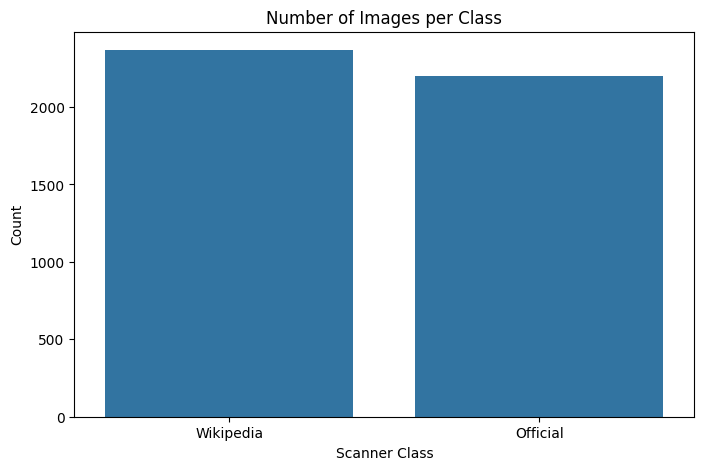

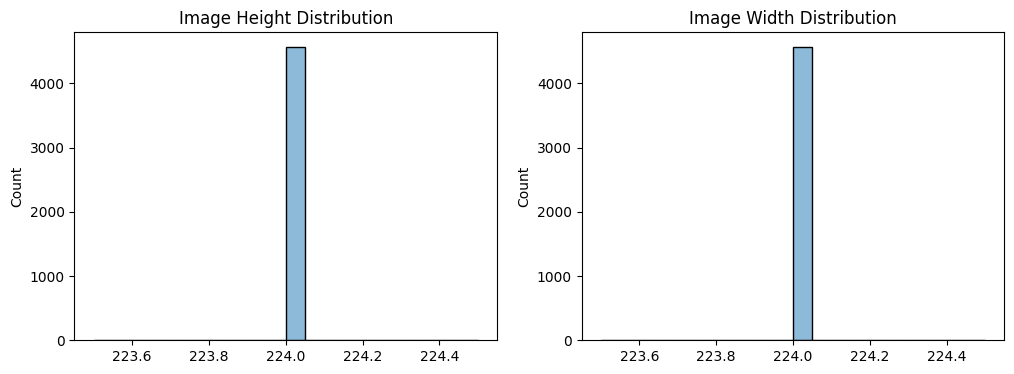

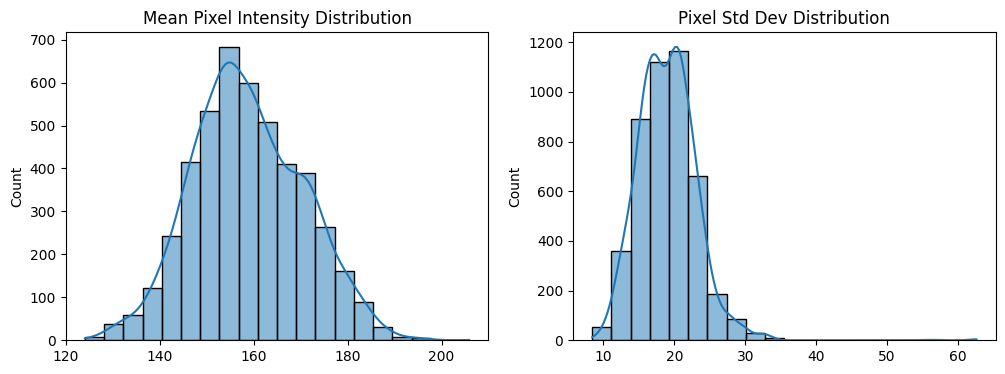

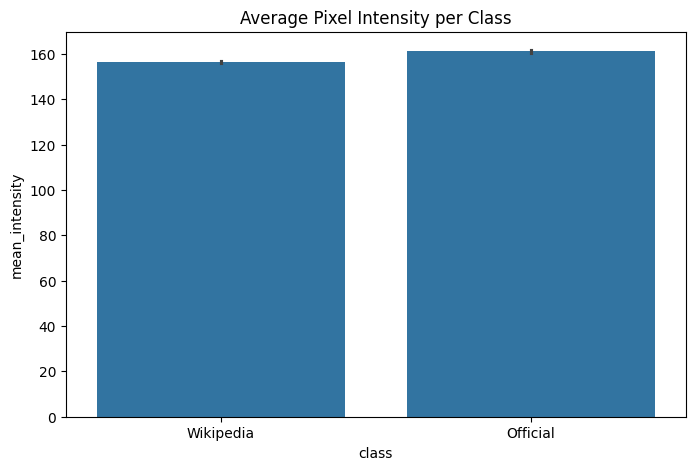


✅ Image Size Stats:
Height - min: 224, max: 224, mean: 224.0
Width  - min: 224, max: 224, mean: 224.0

✅ Pixel Intensity Stats:
Mean pixel intensity - min: 124.01, max: 205.88, mean: 158.74
Std pixel intensity  - min: 8.43, max: 62.58, mean: 19.02


In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import numpy as np

# --- Load metadata ---
metadata_file = "/content/drive/MyDrive/AI_Tracefinder/Supatlantique_preprocessed_docs/metadata_docs.csv"
df = pd.read_csv(metadata_file)

print("✅ Metadata head:")
print(df.head())
print("\n✅ Metadata info:")
print(df.info())
print("\n✅ Class distribution:")
print(df['class'].value_counts())

# --- Plot class distribution ---
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='class', order=df['class'].value_counts().index)
plt.title("Number of Images per Class")
plt.xlabel("Scanner Class")
plt.ylabel("Count")
plt.show()

# --- Check image dimensions and residual stats ---
image_dir = "/content/drive/MyDrive/AI_Tracefinder/Supatlantique_preprocessed_docs"

heights, widths = [], []
means, stds = [], []
valid_rows = []

for idx, row in df.iterrows():
    img_path = os.path.join(image_dir, row['subfolder'], row['filename'])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        # Append None or a placeholder to maintain list length
        heights.append(None)
        widths.append(None)
        means.append(None)
        stds.append(None)
    else:
        heights.append(img.shape[0])
        widths.append(img.shape[1])
        means.append(np.mean(img))
        stds.append(np.std(img))
        valid_rows.append(idx)


# Filter out rows where image could not be read
df_filtered = df.iloc[valid_rows].copy()
heights = [h for h in heights if h is not None]
widths = [w for w in widths if w is not None]
means = [m for m in means if m is not None]
stds = [s for s in stds if s is not None]

# --- Image size distribution ---
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(heights, kde=True, bins=20)
plt.title("Image Height Distribution")
plt.subplot(1,2,2)
sns.histplot(widths, kde=True, bins=20)
plt.title("Image Width Distribution")
plt.show()

# --- Pixel intensity statistics ---
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(means, kde=True, bins=20)
plt.title("Mean Pixel Intensity Distribution")
plt.subplot(1,2,2)
sns.histplot(stds, kde=True, bins=20)
plt.title("Pixel Std Dev Distribution")
plt.show()

# --- Class-wise mean intensity ---
class_stats = df_filtered.copy()
class_stats['mean_intensity'] = means
plt.figure(figsize=(8,5))
sns.barplot(data=class_stats, x='class', y='mean_intensity', order=df['class'].value_counts().index)
plt.title("Average Pixel Intensity per Class")
plt.show()

# --- Quick stats summary ---
print("\n✅ Image Size Stats:")
print(f"Height - min: {np.min(heights)}, max: {np.max(heights)}, mean: {np.mean(heights)}")
print(f"Width  - min: {np.min(widths)}, max: {np.max(widths)}, mean: {np.mean(widths)}")

print("\n✅ Pixel Intensity Stats:")
print(f"Mean pixel intensity - min: {np.min(means):.2f}, max: {np.max(means):.2f}, mean: {np.mean(means):.2f}")
print(f"Std pixel intensity  - min: {np.min(stds):.2f}, max: {np.max(stds):.2f}, mean: {np.mean(stds):.2f}")

visualize sample residual images per class

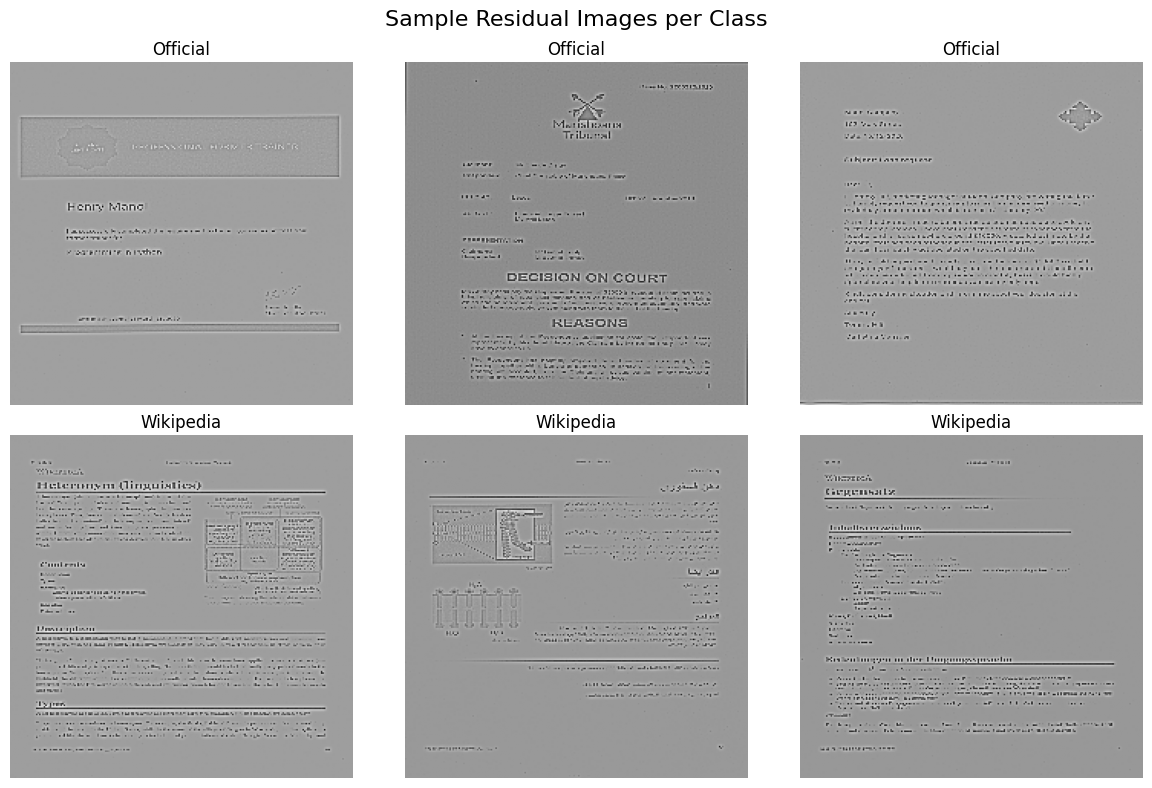

In [19]:
import random
import matplotlib.pyplot as plt
import cv2
import os

# --- Set paths ---
image_dir = "/content/drive/MyDrive/AI_Tracefinder/Supatlantique_preprocessed_docs"

# --- Number of samples per class to display ---
samples_per_class = 3
classes = df['class'].unique()

plt.figure(figsize=(samples_per_class*4, len(classes)*4))

for i, cls in enumerate(classes):
    cls_df = df[df['class'] == cls]
    sample_rows = cls_df.sample(n=min(samples_per_class, len(cls_df)), random_state=42)

    for j, (_, row) in enumerate(sample_rows.iterrows()):
        img_path = os.path.join(image_dir, row['subfolder'], row['filename'])
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        plt_idx = i*samples_per_class + j + 1
        plt.subplot(len(classes), samples_per_class, plt_idx)
        plt.imshow(img, cmap='gray')
        plt.title(f"{cls}")
        plt.axis('off')

plt.suptitle("Sample Residual Images per Class", fontsize=16)
plt.tight_layout()
plt.show()


Checking for corrupted Images in Dataset

In [20]:
import os
import cv2
from google.colab import drive


# Paths
dataset_path = "/content/drive/MyDrive/AI_Tracefinder"
extensions = {".tif"}

corrupted_files = []

# Walk through entire dataset
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if os.path.splitext(file)[1].lower() in extensions:
            file_path = os.path.join(root, file)
            img = cv2.imread(file_path)
            if img is None:
                corrupted_files.append(file_path)

# Print summary
print(f"Total corrupted files found: {len(corrupted_files)}")
if len(corrupted_files) > 0:
    for f in corrupted_files:
        print(f)
else:
    print("No corrupted images found!")


Total corrupted files found: 0
No corrupted images found!
